In [4]:
# ✅ Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     GlobalAveragePooling2D, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [5]:
# ✅ Load Pre-split Dataset
data = np.load("/kaggle/input/dataset/train_test_split.npz")
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

In [6]:
# ✅ Compute Class Weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

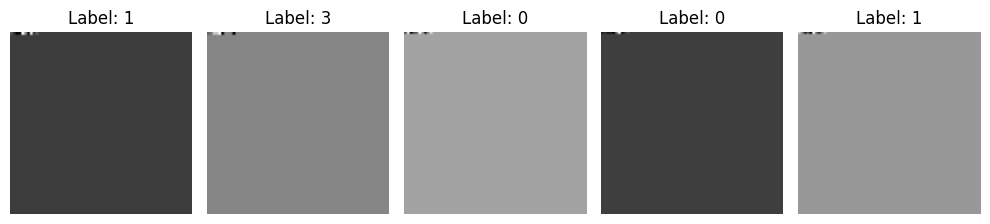

In [8]:
# ✅ Convert Tabular to Image Format
def tabular_to_image(X, img_size=(64, 64)):
    total_pixels = img_size[0] * img_size[1]
    padded = np.zeros((X.shape[0], total_pixels))
    padded[:, :X.shape[1]] = X
    images = padded.reshape(-1, img_size[0], img_size[1], 1)
    return images

X_train_img = tabular_to_image(X_train)
X_test_img = tabular_to_image(X_test)

# ✅ Show Sample Images
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].squeeze(), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# ✅ Optimized CNN Model
def build_model(input_shape=(64, 64, 1), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2, 2)(x)

    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2, 2)(x)

    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2, 2)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3), 
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model()

I0000 00:00:1750564772.306880      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750564772.307567      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
# ✅ Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model_final.keras", monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    X_train_img, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50


I0000 00:00:1750564798.067993      99 service.cc:148] XLA service 0x185d7fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750564798.068633      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750564798.068652      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750564798.440059      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


  10/1751 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.5574 - loss: 1.0237

I0000 00:00:1750564802.462889      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.9190 - loss: 0.2231 - val_accuracy: 0.2769 - val_loss: 20.6804
Epoch 2/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9558 - loss: 0.1180 - val_accuracy: 0.8707 - val_loss: 0.4104
Epoch 3/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9600 - loss: 0.1057 - val_accuracy: 0.4566 - val_loss: 9.9307
Epoch 4/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9604 - loss: 0.1021 - val_accuracy: 0.9593 - val_loss: 0.1060
Epoch 5/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9612 - loss: 0.1003 - val_accuracy: 0.9636 - val_loss: 0.1006
Epoch 6/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9617 - loss: 0.0972 - val_accuracy: 0.9027 - val_loss: 0.2194
Epoch 7/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9629 - loss: 0.0944 - val_accuracy: 0.9590 - val_loss: 0.1065
Epoch 8/50
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9633 - loss: 0.0

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     12581
           1       0.97      0.96      0.97     20027
           2       0.96      0.97      0.97     12130
           3       1.00      1.00      1.00     15275

    accuracy                           0.97     60013
   macro avg       0.97      0.97      0.97     60013
weighted avg       0.97      0.97      0.97     60013



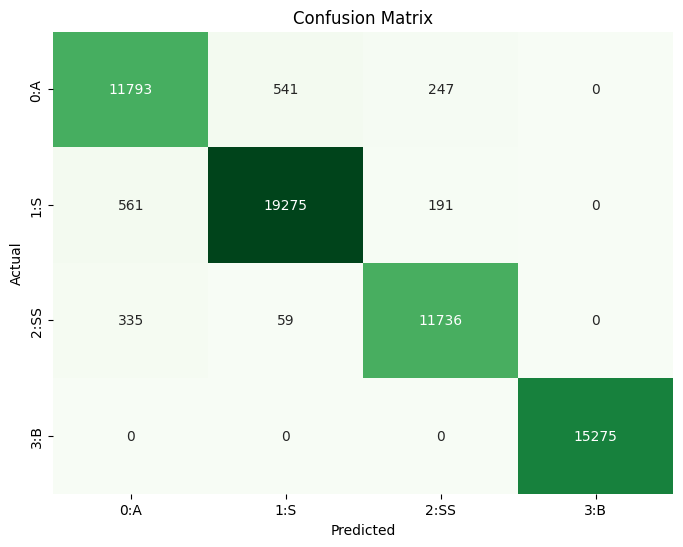

In [12]:
# ✅ Predict and Report
y_pred = model.predict(X_test_img)
y_pred_class = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_class))

# ✅ Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=["0:A", "1:S", "2:SS", "3:B"],
            yticklabels=["0:A", "1:S", "2:SS", "3:B"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [13]:
# ✅ False Positives
fp_per_class = conf_matrix.sum(axis=0) - np.diag(conf_matrix)
total_fp = fp_per_class.sum()
print("\n\U0001F6A8 False Positives per Class:")
for i, fp in enumerate(fp_per_class):
    label = ['A', 'S', 'SS', 'B'][i]
    print(f"  \u27a4 Class {i} (Label: {label}): {fp}")
print("\n❗ Total False Positives:", total_fp)

# ✅ Save Final Model (KERAS format)
model.save("final_model_clean.keras")
print("\n✅ Final model saved as final_model_clean.keras")


🚨 False Positives per Class:
  ➤ Class 0 (Label: A): 896
  ➤ Class 1 (Label: S): 600
  ➤ Class 2 (Label: SS): 438
  ➤ Class 3 (Label: B): 0

❗ Total False Positives: 1934

✅ Final model saved as final_model_clean.keras
